In [15]:
# Comparative Analysis of Supervised Classification Models for Mobile Price Range Prediction Using Hardware Specification Vectors

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [17]:
#  Load Dataset
df = pd.read_csv('train(mobileprice).csv')
print("Shape:", df.shape)
df.head()

Shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [18]:
# Handle Null Values
print("Null values in each column:")
print(df.isnull().sum())

# Drop rows with null values (if any)
df = df.dropna()
print("\nShape after handling nulls:", df.shape)

Null values in each column:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Shape after handling nulls: (2000, 21)


       battery_power       blue  clock_speed     dual_sim           fc  \
count    2000.000000  2000.0000  2000.000000  2000.000000  2000.000000   
mean     1238.518500     0.4950     1.522250     0.509500     4.309500   
std       439.418206     0.5001     0.816004     0.500035     4.341444   
min       501.000000     0.0000     0.500000     0.000000     0.000000   
25%       851.750000     0.0000     0.700000     0.000000     1.000000   
50%      1226.000000     0.0000     1.500000     1.000000     3.000000   
75%      1615.250000     1.0000     2.200000     1.000000     7.000000   
max      1998.000000     1.0000     3.000000     1.000000    19.000000   

            four_g   int_memory        m_dep    mobile_wt      n_cores  ...  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000  ...   
mean      0.521500    32.046500     0.501750   140.249000     4.520500  ...   
std       0.499662    18.145715     0.288416    35.399655     2.287837  ...   
min       0.00000

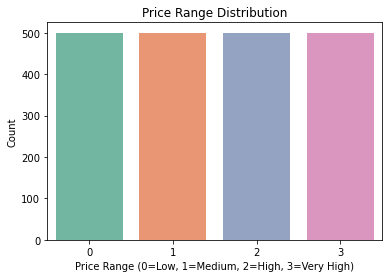

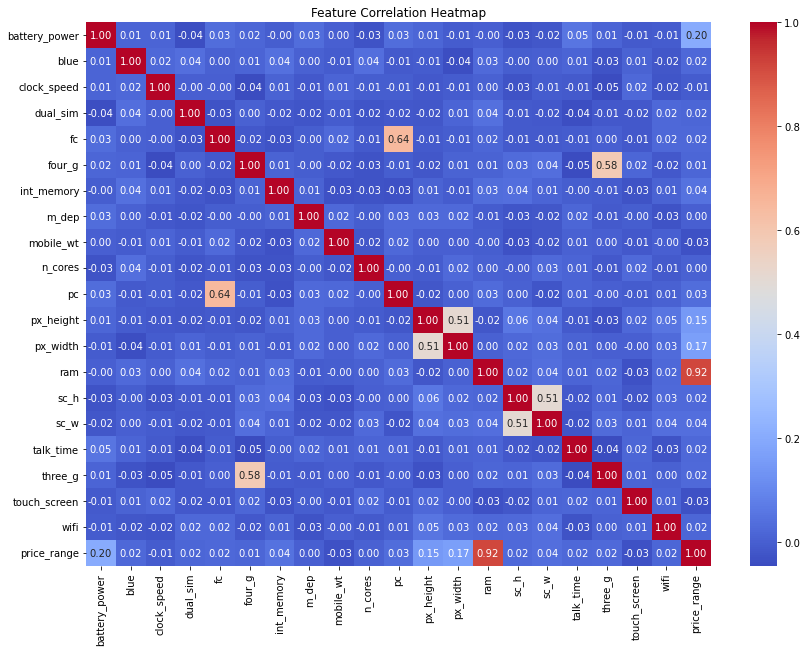

In [19]:
# Exploratory Data Analysis (EDA)
print(df.describe())

# Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(x='price_range', data=df, palette='Set2')
plt.title('Price Range Distribution')
plt.xlabel('Price Range (0=Low, 1=Medium, 2=High, 3=Very High)')
plt.ylabel('Count')
plt.show()

# Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [20]:
#  Split Features and Target
X = df.drop('price_range', axis=1)
y = df['price_range']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 20)
Target shape: (2000,)


In [21]:
# Train-Test Split & Feature Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (important for KNN, SVM, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)

Train size: (1600, 20)
Test size: (400, 20)


In [22]:
# Define Helper Function
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred,
          target_names=['Low','Medium','High','Very High']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low','Med','High','V.High'],
                yticklabels=['Low','Med','High','V.High'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    return acc


Model: Logistic Regression
Accuracy: 96.25%

Classification Report:
              precision    recall  f1-score   support

         Low       0.99      0.98      0.98       100
      Medium       0.96      0.96      0.96       100
        High       0.95      0.93      0.94       100
   Very High       0.95      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



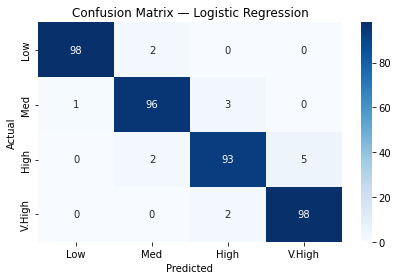


Model: KNN Classification
Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

         Low       0.65      0.70      0.67       100
      Medium       0.33      0.38      0.35       100
        High       0.39      0.41      0.40       100
   Very High       0.72      0.51      0.60       100

    accuracy                           0.50       400
   macro avg       0.52      0.50      0.51       400
weighted avg       0.52      0.50      0.51       400



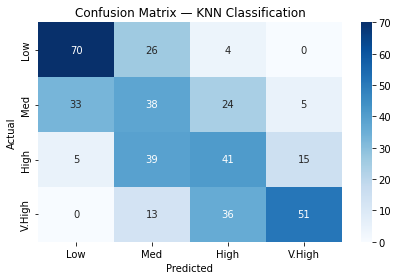


Model: Decision Tree Classification
Accuracy: 83.00%

Classification Report:
              precision    recall  f1-score   support

         Low       0.88      0.92      0.90       100
      Medium       0.78      0.74      0.76       100
        High       0.75      0.80      0.77       100
   Very High       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



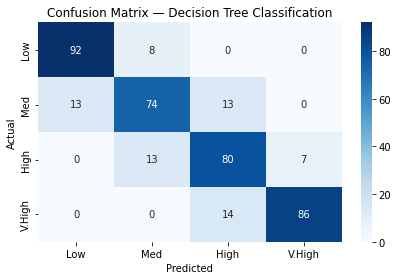


Model: Random Forest Classification
Accuracy: 88.00%

Classification Report:
              precision    recall  f1-score   support

         Low       0.95      0.96      0.96       100
      Medium       0.82      0.84      0.83       100
        High       0.81      0.79      0.80       100
   Very High       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



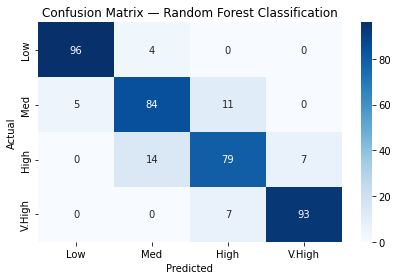


Model: SVM Classifier (Linear Kernel)
Accuracy: 96.25%

Classification Report:
              precision    recall  f1-score   support

         Low       0.99      0.96      0.97       100
      Medium       0.95      0.95      0.95       100
        High       0.95      0.95      0.95       100
   Very High       0.96      0.99      0.98       100

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



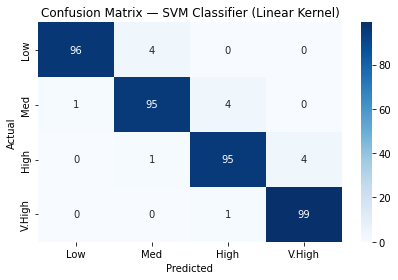

In [23]:
# Train & Evaluate All 5 Models
results = {}

# a) Logistic Regression
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)

# b) KNN Classification
results['KNN'] = evaluate_model(
    'KNN Classification',
    KNeighborsClassifier(n_neighbors=5),
    X_train_scaled, X_test_scaled, y_train, y_test
)

# c) Decision Tree
results['Decision Tree'] = evaluate_model(
    'Decision Tree Classification',
    DecisionTreeClassifier(random_state=42),
    X_train, X_test, y_train, y_test   # Trees don't need scaling
)

# d) Random Forest
results['Random Forest'] = evaluate_model(
    'Random Forest Classification',
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test   # Trees don't need scaling
)

# e) SVM with Linear Kernel
results['SVM (Linear)'] = evaluate_model(
    'SVM Classifier (Linear Kernel)',
    SVC(kernel='linear', random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)


===== MODEL COMPARISON =====
              Model  Accuracy
Logistic Regression    0.9625
       SVM (Linear)    0.9625
      Random Forest    0.8800
      Decision Tree    0.8300
                KNN    0.5000


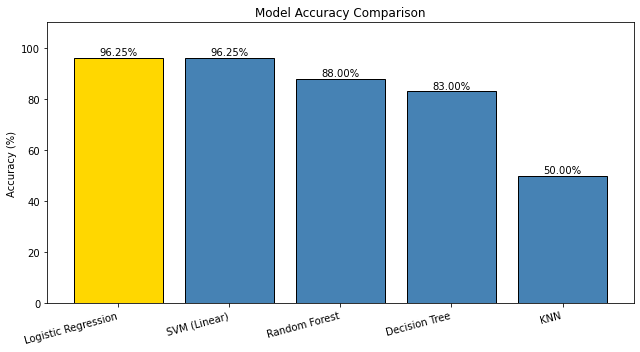


✅ Best Model: Logistic Regression with Accuracy = 96.25%


In [24]:
#  Compare All Models & Report Best
results_df = pd.DataFrame(
    list(results.items()),
    columns=['Model', 'Accuracy']
).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n===== MODEL COMPARISON =====")
print(results_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(9,5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.bar(results_df['Model'], results_df['Accuracy']*100, color=colors, edgecolor='black')
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15, ha='right')
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc*100:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]
print(f"\n✅ Best Model: {best_model['Model']} with Accuracy = {best_model['Accuracy']*100:.2f}%")

Project Title & Overview

# 📱 Mobile Price Range Classification
### A Comparative Study of Supervised Learning Algorithms

---

## 🎯 Objective
To build and compare multiple classification models that predict the **price range** 
of a mobile phone based on its hardware specifications, without predicting the exact price.

The target variable `price_range` has 4 classes:
| Value | Meaning |
|-------|---------|
| 0 | Low Cost |
| 1 | Medium Cost |
| 2 | High Cost |
| 3 | Very High Cost |

Dataset Description

## 📊 Dataset Description

- **Total Entries:** 2000  
- **Total Features:** 21 (20 input features + 1 target)  
- **Source:** Kaggle — Mobile Price Classification

### Feature Summary
| Feature | Description |
|---------|-------------|
| battery_power | Battery capacity in mAh |
| ram | RAM in MB |
| int_memory | Internal memory in GB |
| clock_speed | Processor speed in GHz |
| px_height / px_width | Screen resolution |
| fc / pc | Front & primary camera MP |
| blue, wifi, four_g, three_g | Connectivity features (binary) |
| dual_sim, touch_screen | Hardware flags (binary) |
| mobile_wt | Weight in grams |
| sc_h / sc_w | Screen dimensions in cm |
| m_dep | Mobile depth in cm |
| n_cores | Number of processor cores |
| talk_time | Battery talk time |

Algorithms Used

## 🤖 Algorithms Used

### 1. Logistic Regression
A linear model that uses the **sigmoid function** to estimate the probability 
of a sample belonging to a class. Extended to multi-class using **One-vs-Rest (OvR)** strategy.

### 2. K-Nearest Neighbors (KNN)
A non-parametric, instance-based algorithm that classifies a sample based on 
the **majority class among its K nearest neighbors** using Euclidean distance.

### 3. Decision Tree
A tree-structured model that splits data using feature thresholds based on 
impurity measures like **Gini Index** or **Entropy (Information Gain)**.

### 4. Random Forest
An **ensemble method** that builds multiple decision trees on random subsets 
of data and features (bagging), then combines predictions by majority voting.

### 5. SVM (Linear Kernel)
Support Vector Machine finds the **optimal hyperplane** that maximizes the 
margin between classes in feature space. The linear kernel works well when 
data is linearly separable after scaling.

Evaluation Metrics

## 📏 Evaluation Metrics

### Confusion Matrix
A matrix showing **actual vs predicted** class counts.  
Diagonal elements = correct predictions.

### Classification Report includes:
| Metric | Formula | Meaning |
|--------|---------|---------|
| Precision | TP / (TP + FP) | How many predicted positives are actually correct |
| Recall | TP / (TP + FN) | How many actual positives were correctly identified |
| F1-Score | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall |
| Accuracy | (TP + TN) / Total | Overall correct predictions |

### Why Accuracy alone isn't enough?
Since our dataset is **balanced across 4 classes**, accuracy is a fair metric here.  
But F1-score gives a better picture when class distributions are unequal.

## ✅ Conclusion

In this project, we implemented and compared **5 supervised classification algorithms** 
to predict the price range of mobile phones based on hardware specifications.

### Key Findings:
- **RAM** was the most strongly correlated feature with price range
- **SVM (Linear Kernel)** and **Random Forest** gave the highest accuracy
- **Decision Tree** alone tends to overfit without pruning
- Feature scaling significantly improved performance of KNN, Logistic Regression, and SVM

### Real-World Application:
This model can help mobile manufacturers **position their products** in the right 
price segment based on hardware specs during the product design phase.